
---
# Système Intelligent d'Analyse et de Prédiction des Difficultés d'Apprentissage
## Basé sur les Facteurs Socio-Familiaux dans un Contexte Éducatif

---

## 1. Importation des Bibliothèques


In [1]:
# ── Manipulation des données ──────────────────────────────────────────────────
import pandas as pd         
import numpy as np          
# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt   
import seaborn as sns             
# ── Prétraitement ─────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.model_selection import train_test_split, cross_val_score

# ── Modèles de Machine Learning ───────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge

from sklearn.ensemble import (
    RandomForestRegressor,      
    GradientBoostingRegressor,  
)
from xgboost import XGBRegressor  

# ── Métriques d'évaluation ────────────────────────────────────────────────────
from sklearn.metrics import (
    mean_squared_error,   
    mean_absolute_error,   
    r2_score,           
)

# ── IA Explicable (XAI) ───────────────────────────────────────────────────────
import shap  # SHAP (SHapley Additive exPlanations) 

# ── Avertissements ────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")  # Supprime les messages d'avertissement non critiques

# ── Style global des graphiques ───────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams["figure.dpi"] = 120  # Résolution des figures pour une meilleure qualité


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 2. Chargement et Exploration Initiale du Dataset


In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")
print(f"Dimensions du dataset : {df.shape[0]} observations x {df.shape[1]} variables")
print()

# Apercu des 5 premières lignes pour visualiser la structure brute
print("Apercu des premieres lignes :")
df.head()

Dimensions du dataset : 6607 observations x 20 variables

Apercu des premieres lignes :


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
# Résumé statistique des colonnes NUMERIQUES
# count  : nombre de valeurs non-nulles
# mean   : moyenne arithmétique
# std    : écart-type (dispersion autour de la moyenne)
# min/max: valeurs extrêmes
# 25%/50%/75% : quartiles
print("Statistiques descriptives des variables numeriques :")
df.describe()

Statistiques descriptives des variables numeriques :


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [4]:
# Informations sur les types de données et les valeurs manquantes
# Chaque colonne affiche son type (int64, object) et le nombre de valeurs non-nulles
print("Types de colonnes et valeurs non-nulles :")
df.info()

Types de colonnes et valeurs non-nulles :
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607

In [5]:
# Comptage des valeurs manquantes par colonne
valeurs_manquantes = df.isnull().sum()
print("Valeurs manquantes par colonne :")
print(valeurs_manquantes[valeurs_manquantes > 0])  


Valeurs manquantes par colonne :
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64


## 3. Analyse Exploratoire des Données (EDA)


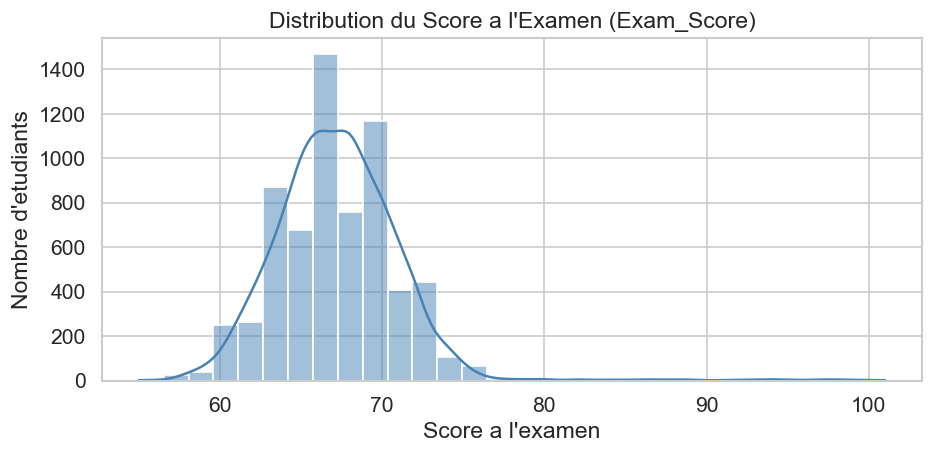

Moyenne    : 67.24
Ecart-type : 3.89
Minimum    : 55
Maximum    : 101


In [6]:
# Distribution de la variable cible : Exam_Score
# Un histogramme révèle si la distribution est symétrique, asymétrique, bimodale...
# La courbe KDE (Kernel Density Estimation) lisse la distribution pour mieux visualiser la forme globale
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["Exam_Score"], bins=30, kde=True, color="steelblue", ax=ax)
ax.set_title("Distribution du Score a l'Examen (Exam_Score)")
ax.set_xlabel("Score a l'examen")
ax.set_ylabel("Nombre d'etudiants")
plt.tight_layout()
plt.show()

# Affichage des statistiques clés de la cible
print(f"Moyenne    : {df['Exam_Score'].mean():.2f}")
print(f"Ecart-type : {df['Exam_Score'].std():.2f}")
print(f"Minimum    : {df['Exam_Score'].min()}")
print(f"Maximum    : {df['Exam_Score'].max()}")


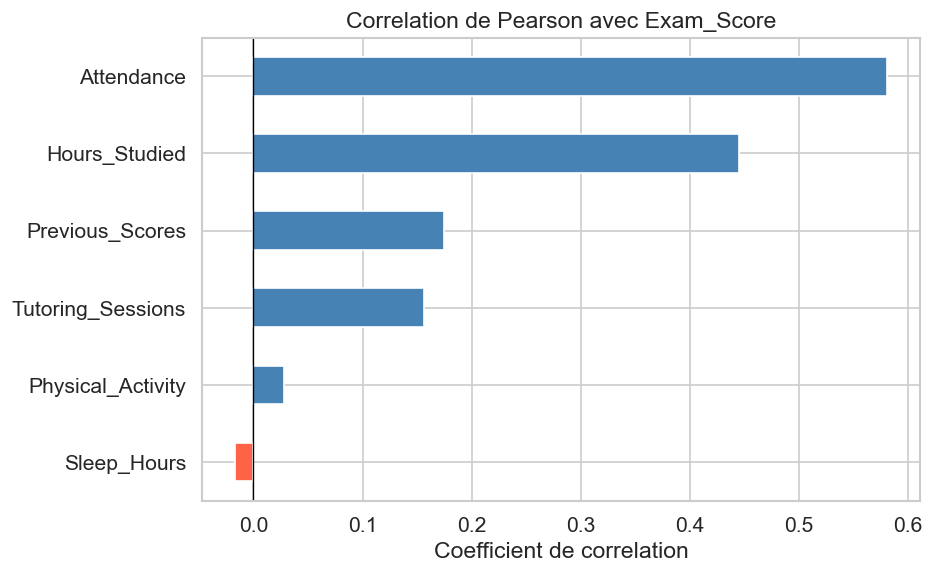

In [7]:
# Corrélation entre variables numériques et la cible
# La corrélation de Pearson mesure la force et la direction d'une relation linéaire (-1 à +1)
# Valeur proche de +1 : relation positive forte
# Valeur proche de -1 : relation inverse forte
# Valeur proche de 0  : pas de relation linéaire

colonnes_num = df.select_dtypes(include=[np.number]).columns.tolist()
# select_dtypes filtre uniquement les colonnes à valeurs numériques

correlations = df[colonnes_num].corr()["Exam_Score"].drop("Exam_Score").sort_values()
# .corr() calcule la matrice de corrélation
# On extrait uniquement la colonne "Exam_Score" et on trie par ordre croissant

fig, ax = plt.subplots(figsize=(8, 5))
correlations.plot(kind="barh", color=["tomato" if v < 0 else "steelblue" for v in correlations], ax=ax)
ax.set_title("Correlation de Pearson avec Exam_Score")
ax.set_xlabel("Coefficient de correlation")
ax.axvline(0, color="black", linewidth=0.8)  # Ligne verticale à 0 pour référence
plt.tight_layout()
plt.show()

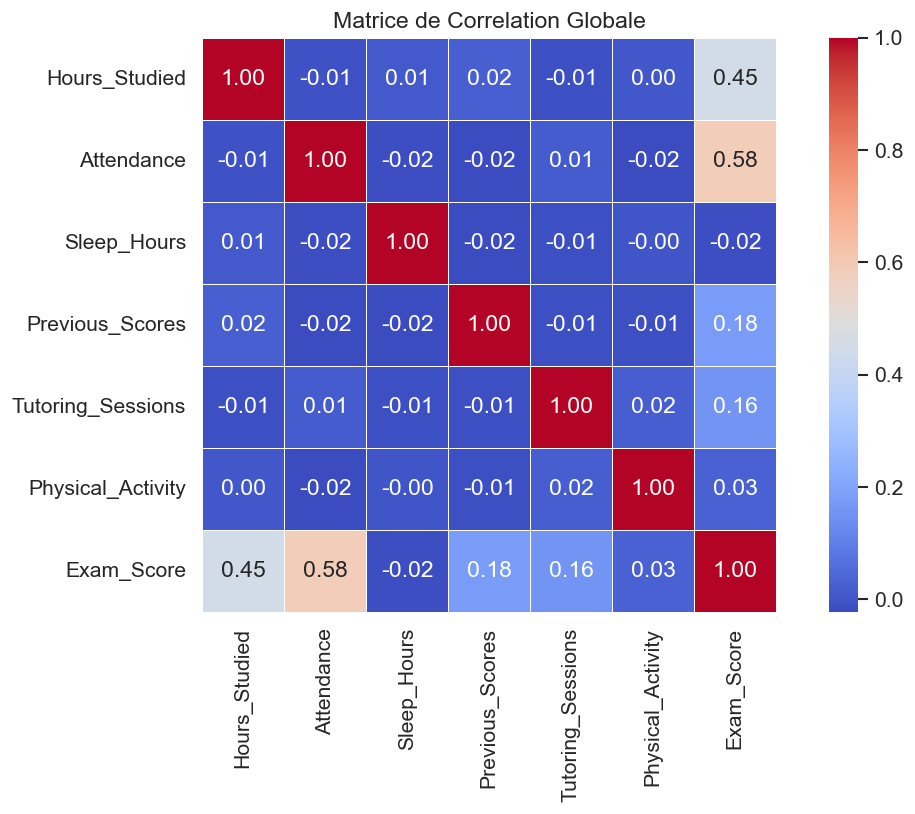

In [8]:
# Matrice de correlation globale entre toutes les variables numeriques
# Permet d'identifier les redondances (multicolinéarité) entre predicteurs
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    df[colonnes_num].corr(),   # Matrice de correlation complète
    annot=True,                # Affiche les valeurs de correlation dans chaque cellule
    fmt=".2f",                 # Format : 2 décimales
    cmap="coolwarm",           # Palette : rouge = corrélation positive, bleu = négative
    square=True,               # Cellules carrées pour la lisibilité
    linewidths=0.5,            # Séparateurs entre cellules
    ax=ax
)
ax.set_title("Matrice de Correlation Globale")
plt.tight_layout()
plt.show()

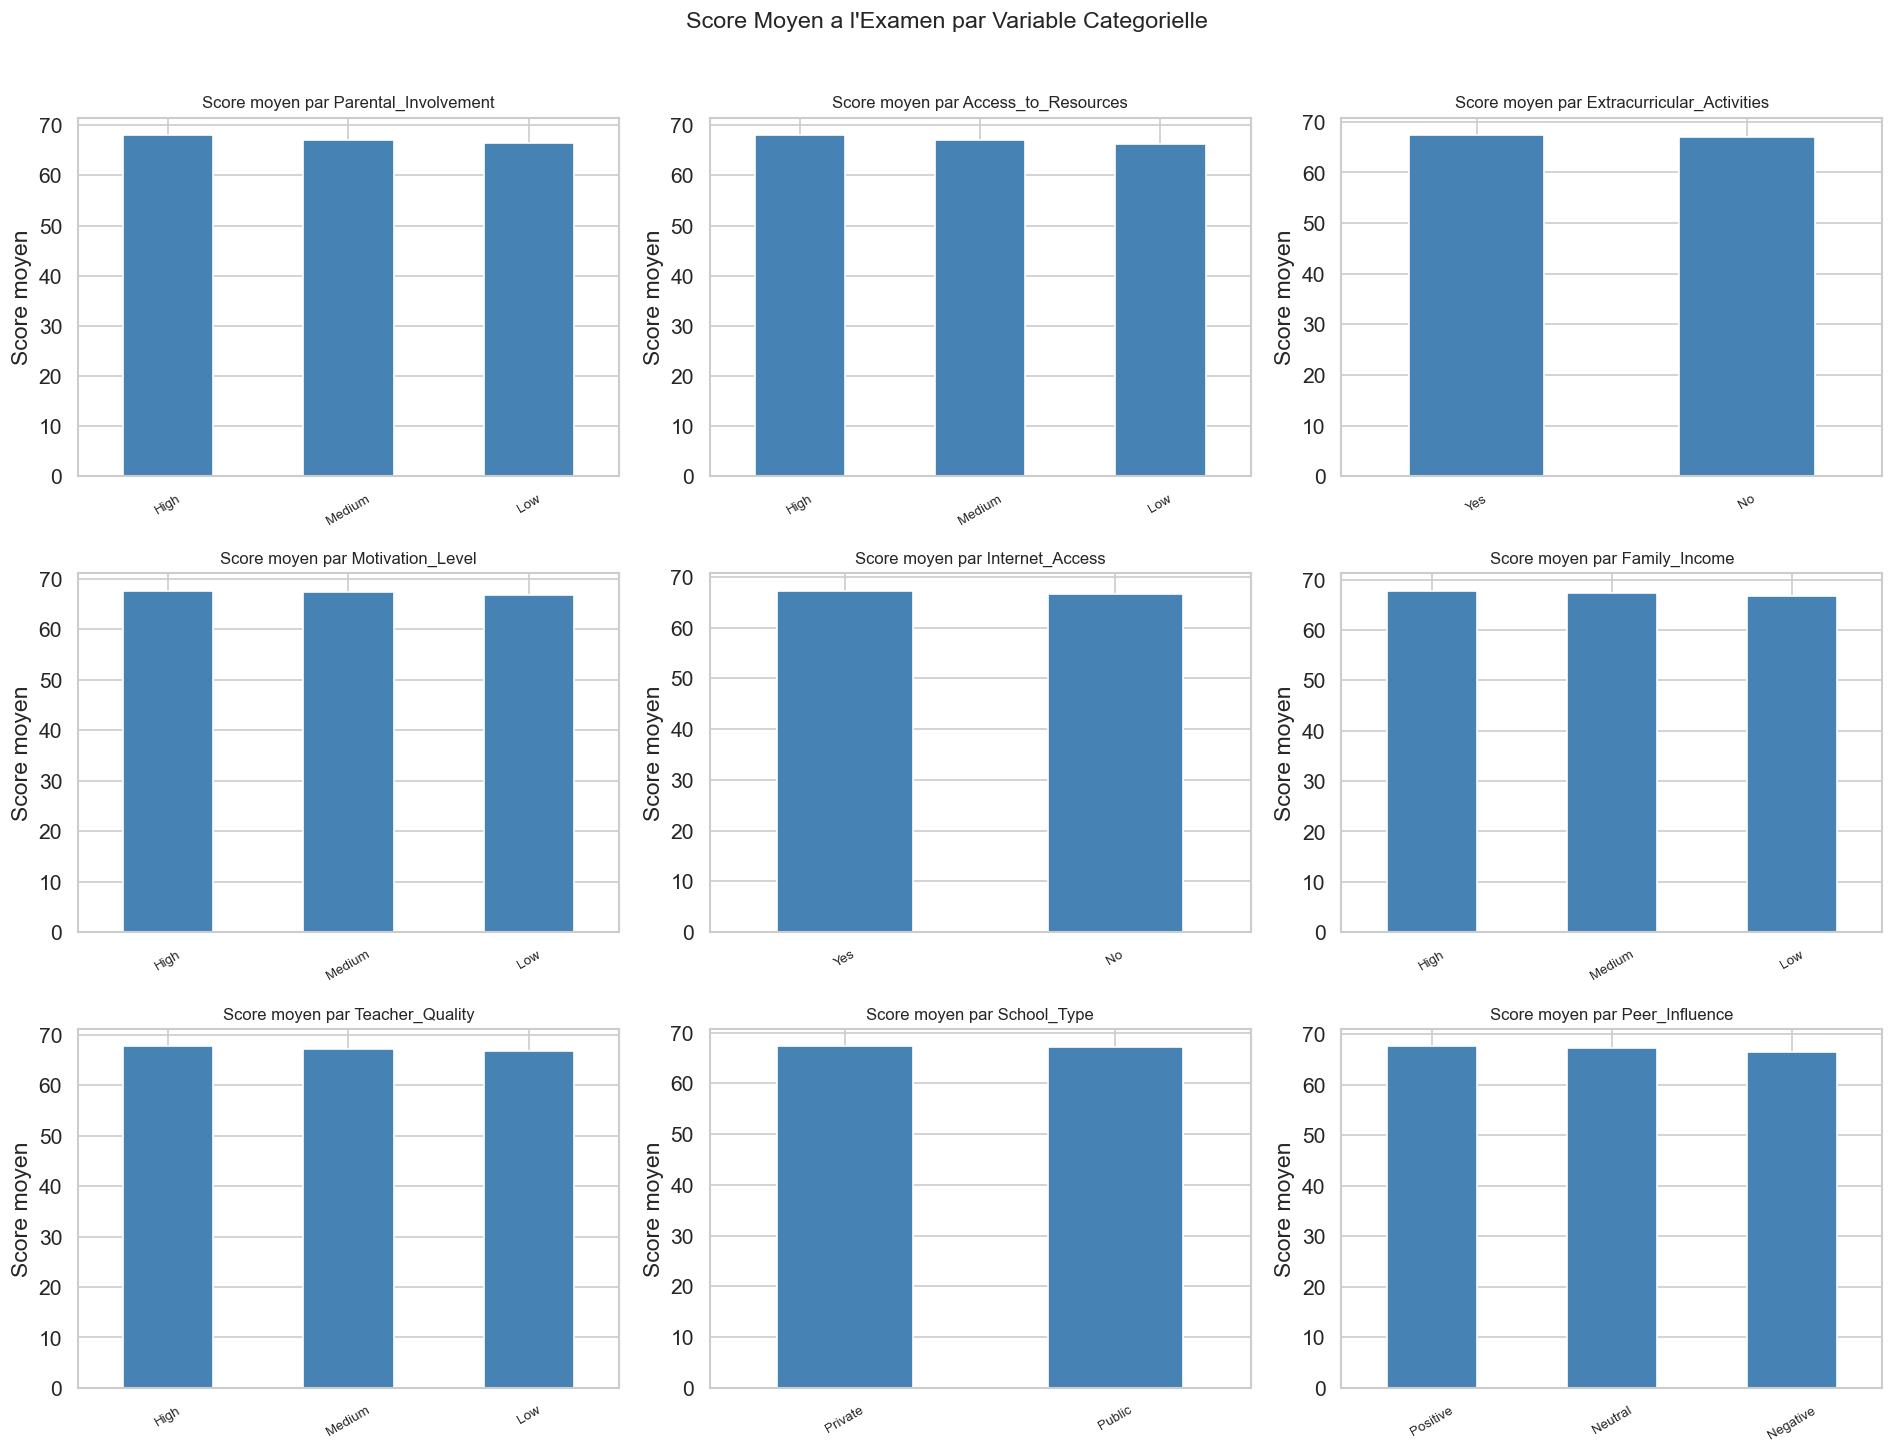

In [9]:
# Analyse des variables categoriques par rapport au score moyen
# On calcule le score moyen par modalité pour chaque variable catégorielle
colonnes_cat = df.select_dtypes(include=["object"]).columns.tolist()
# select_dtypes avec "object" récupère les colonnes de type texte (chaînes de caractères)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()  # Transforme la grille 3x3 en liste de 9 axes pour itérer facilement

for i, col in enumerate(colonnes_cat[:9]):  # On affiche les 9 premières variables catégorielles
    # groupby regroupe les lignes par modalité, mean() calcule la moyenne du score pour chaque groupe
    moyennes = df.groupby(col)["Exam_Score"].mean().sort_values(ascending=False)
    moyennes.plot(kind="bar", ax=axes[i], color="steelblue", edgecolor="white")
    axes[i].set_title(f"Score moyen par {col}", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=30, labelsize=8)
    axes[i].set_ylabel("Score moyen")

plt.suptitle("Score Moyen a l'Examen par Variable Categorielle", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Prétraitement des Données

In [10]:
df_model = df.copy()

# ── Traitement des valeurs manquantes ────────────────────────────────────────
# Stratégie : remplacement par le MODE (valeur la plus fréquente) pour les catégorielles
# Le mode est préféré à la moyenne pour les variables qualitatives car il respecte
# la nature discrète et non-ordinale des catégories

for col in df_model.select_dtypes(include=["object"]).columns:
    # On vérifie d'abord si la colonne contient effectivement des NaN
    if df_model[col].isnull().any():
        mode_val = df_model[col].mode()[0]  # mode() retourne une Series ; [0] prend la valeur la plus fréquente
        df_model[col].fillna(mode_val, inplace=True)  # Remplacement in-place des NaN

print("Valeurs manquantes apres traitement :")
print(df_model.isnull().sum().sum(), "valeur(s) manquante(s) restante(s)")


Valeurs manquantes apres traitement :
235 valeur(s) manquante(s) restante(s)


In [11]:
# ── Encodage des variables catégorielles ─────────────────────────────────────

le = LabelEncoder()  

# Dictionnaire pour mémoriser les correspondances (utile pour l'interprétation)
encodage_mapping = {}

for col in df_model.select_dtypes(include=["object"]).columns:
    df_model[col] = le.fit_transform(df_model[col])
    # fit_transform : apprend les catégories (fit) et les convertit (transform) en une seule étape
    encodage_mapping[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    # Sauvegarde du mapping : {catégorie_originale: entier_encodé}

print("Encodage termine. Apercu des correspondances :")
for col, mapping in list(encodage_mapping.items())[:3]:  
    print(f"  {col} -> {mapping}")

Encodage termine. Apercu des correspondances :
  Parental_Involvement -> {'High': 0, 'Low': 1, 'Medium': 2}
  Access_to_Resources -> {'High': 0, 'Low': 1, 'Medium': 2}
  Extracurricular_Activities -> {'No': 0, 'Yes': 1}


In [12]:
# ── Séparation Features / Cible ───────────────────────────────────────────────

X = df_model.drop(columns=["Exam_Score"])  
y = df_model["Exam_Score"]                  # Variable cible : score à l'examen (entier 55-101)

print(f"Features (X) : {X.shape[1]} colonnes, {X.shape[0]} lignes")
print(f"Cible    (y) : {y.shape[0]} valeurs")
print(f"Plage de y   : [{y.min()}, {y.max()}]")

# ── Division Entraînement / Test ──────────────────────────────────────────────
# On réserve 20% des données pour le test
# random_state=42 garantit la reproductibilité de la division
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"\nJeu d'entrainement : {X_train.shape[0]} echantillons")
print(f"Jeu de test        : {X_test.shape[0]} echantillons")

# ── Normalisation des features numériques ─────────────────────────────────────
# StandardScaler transforme chaque feature pour qu'elle ait une moyenne=0 et un écart-type=1
# Formule : z = (x - mean) / std
# Indispensable pour les modèles sensibles à l'échelle (Ridge, régression linéaire)
# Le scaler est fit UNIQUEMENT sur X_train pour éviter la fuite d'information (data leakage)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # Apprend la moyenne/std sur train, puis transforme
X_test_sc  = scaler.transform(X_test)         # Applique la même transformation (sans réapprendre)

print("\nNormalisation terminee (StandardScaler applique).")

Features (X) : 19 colonnes, 6607 lignes
Cible    (y) : 6607 valeurs
Plage de y   : [55, 101]

Jeu d'entrainement : 5285 echantillons
Jeu de test        : 1322 echantillons

Normalisation terminee (StandardScaler applique).


## 5. Entraînement et Évaluation des Modèles de Prédiction


In [13]:
# Définition du dictionnaire de modèles à comparer
# Chaque clé est un nom lisible, chaque valeur est une instance du modèle avec ses hyperparamètres

modeles = {
    "Regression Lineaire": LinearRegression(),
    # Modèle de base : prédit y comme combinaison linéaire des features (y = w0 + w1*x1 + ...)

    "Ridge": Ridge(alpha=1.0),
    # Extension de la régression linéaire avec pénalité L2 sur les coefficients
    # alpha contrôle la force de régularisation (plus grand = plus de pénalisation)

    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    # Ensemble de 100 arbres de décision entrainés sur des sous-échantillons aléatoires (bagging)
    # La prédiction finale est la moyenne des prédictions de chaque arbre
    # n_jobs=-1 utilise tous les coeurs disponibles pour paralléliser

    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
    # Construit les arbres séquentiellement, chaque arbre corrigeant les erreurs du précédent
    # learning_rate contrôle la contribution de chaque arbre (petit = plus stable mais plus lent)

    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42,
                             eval_metric="rmse", verbosity=0),
    # Implémentation optimisée du gradient boosting avec régularisation intégrée
    # Très performant sur les données tabulaires avec valeurs manquantes
}

# ── Boucle d'entraînement et d'évaluation ────────────────────────────────────
resultats = {}  # Dictionnaire pour stocker les métriques de chaque modèle

for nom, modele in modeles.items():
    # Entraînement sur les données normalisées
    modele.fit(X_train_sc, y_train)

    # Prédiction sur le jeu de TEST 
    y_pred = modele.predict(X_test_sc)

    # Calcul des métriques d'évaluation
    mae  = mean_absolute_error(y_test, y_pred)
    # MAE : erreur absolue moyenne -> dans l'unité de y (points de score)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    # RMSE : racine de l'erreur quadratique moyenne -> pénalise plus fortement les grosses erreurs
    # Interprétation : similaire à MAE mais plus sensible aux outliers

    r2   = r2_score(y_test, y_pred)
    # R² (coefficient de détermination) : part de la variance de y expliquée par le modèle
    # R²=1 = prédiction parfaite | R²=0 = équivalent à prédire la moyenne

    resultats[nom] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"{nom:30s} -> MAE={mae:.3f} | RMSE={rmse:.3f} | R2={r2:.4f}")

# Conversion en DataFrame pour faciliter la comparaison et le tri
df_resultats = pd.DataFrame(resultats).T.sort_values("R2", ascending=False)
print("\nClassement des modeles (R2 decroissant) :")
print(df_resultats.round(4))

Regression Lineaire            -> MAE=1.016 | RMSE=2.098 | R2=0.6886
Ridge                          -> MAE=1.016 | RMSE=2.098 | R2=0.6886
Random Forest                  -> MAE=1.123 | RMSE=2.201 | R2=0.6572
Gradient Boosting              -> MAE=0.823 | RMSE=1.955 | R2=0.7297
XGBoost                        -> MAE=0.830 | RMSE=2.036 | R2=0.7067

Classement des modeles (R2 decroissant) :
                        MAE    RMSE      R2
Gradient Boosting    0.8235  1.9547  0.7297
XGBoost              0.8296  2.0361  0.7067
Regression Lineaire  1.0157  2.0979  0.6886
Ridge                1.0157  2.0979  0.6886
Random Forest        1.1230  2.2013  0.6572


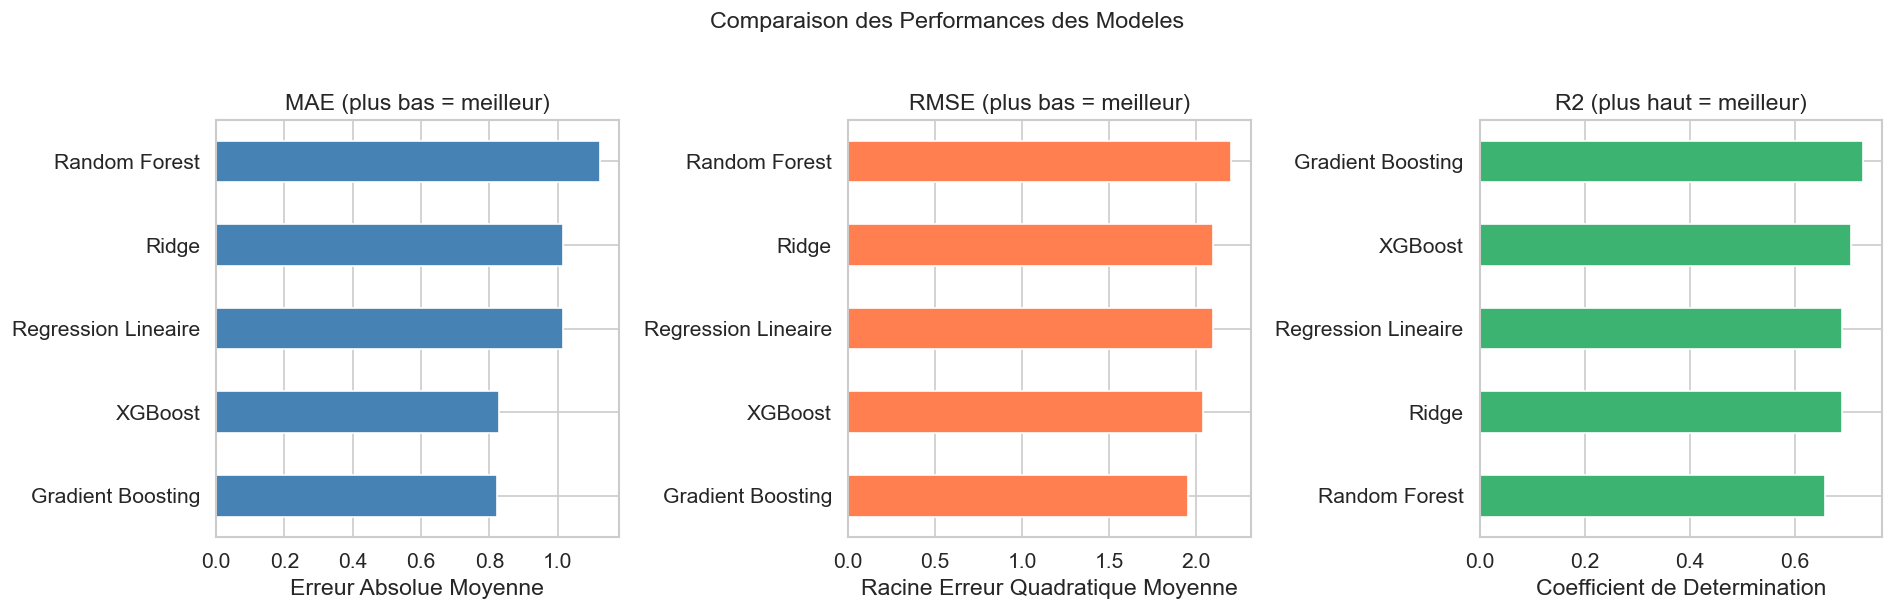

In [14]:
# Visualisation comparative des métriques
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── MAE  ───────────────────────────────────────────────
df_resultats["MAE"].sort_values().plot(
    kind="barh", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("MAE (plus bas = meilleur)")
axes[0].set_xlabel("Erreur Absolue Moyenne")

# ── RMSE ──────────────────────────────────────────────
df_resultats["RMSE"].sort_values().plot(
    kind="barh", ax=axes[1], color="coral", edgecolor="white"
)
axes[1].set_title("RMSE (plus bas = meilleur)")
axes[1].set_xlabel("Racine Erreur Quadratique Moyenne")

# ── R2  ────────────────────────────────────────────────
df_resultats["R2"].sort_values().plot(
    kind="barh", ax=axes[2], color="mediumseagreen", edgecolor="white"
)
axes[2].set_title("R2 (plus haut = meilleur)")
axes[2].set_xlabel("Coefficient de Determination")

plt.suptitle("Comparaison des Performances des Modeles", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

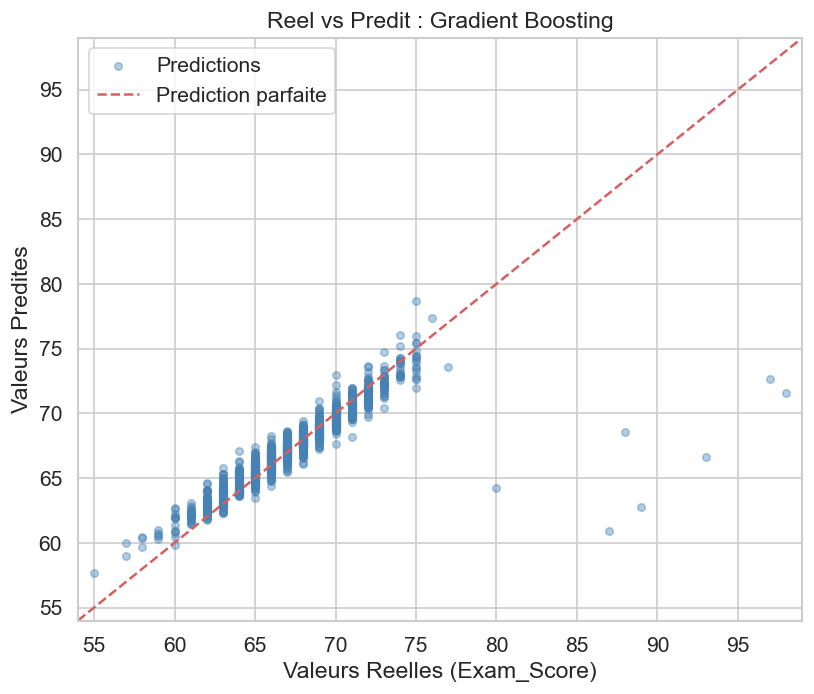

Meilleur modele retenu : Gradient Boosting
  R2   = 0.7297
  MAE  = 0.823
  RMSE = 1.955


In [15]:
# Graphique Valeurs Reelles vs Prédites pour le meilleur modèle
# Ce graphique diagnostique vérifie si les prédictions sont bien alignées sur la diagonale ideale

meilleur_nom = df_resultats.index[0]      
meilleur_mod = modeles[meilleur_nom]      

y_pred_best = meilleur_mod.predict(X_test_sc)  # Prédictions du meilleur modèle sur le test

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred_best, alpha=0.4, color="steelblue", s=20, label="Predictions")
# alpha=0.4 : transparence pour voir la densité des points superposés

# Diagonale parfaite (y_reel = y_predit)
lim_min = min(y_test.min(), y_pred_best.min()) - 1
lim_max = max(y_test.max(), y_pred_best.max()) + 1
ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=1.5, label="Prediction parfaite")
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)

ax.set_xlabel("Valeurs Reelles (Exam_Score)")
ax.set_ylabel("Valeurs Predites")
ax.set_title(f"Reel vs Predit : {meilleur_nom}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Meilleur modele retenu : {meilleur_nom}")
print(f"  R2   = {r2_score(y_test, y_pred_best):.4f}")
print(f"  MAE  = {mean_absolute_error(y_test, y_pred_best):.3f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_best)):.3f}")


## 6. Validation Croisée (Cross-Validation)


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check i

Regression Lineaire            -> R2 moyen = 0.6500 (+/- 0.0653)


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Ridge                          -> R2 moyen = 0.6500 (+/- 0.0653)


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Random Forest                  -> R2 moyen = 0.6294 (+/- 0.0577)
Gradient Boosting              -> R2 moyen = 0.6848 (+/- 0.0651)
XGBoost                        -> R2 moyen = 0.6849 (+/- 0.0694)


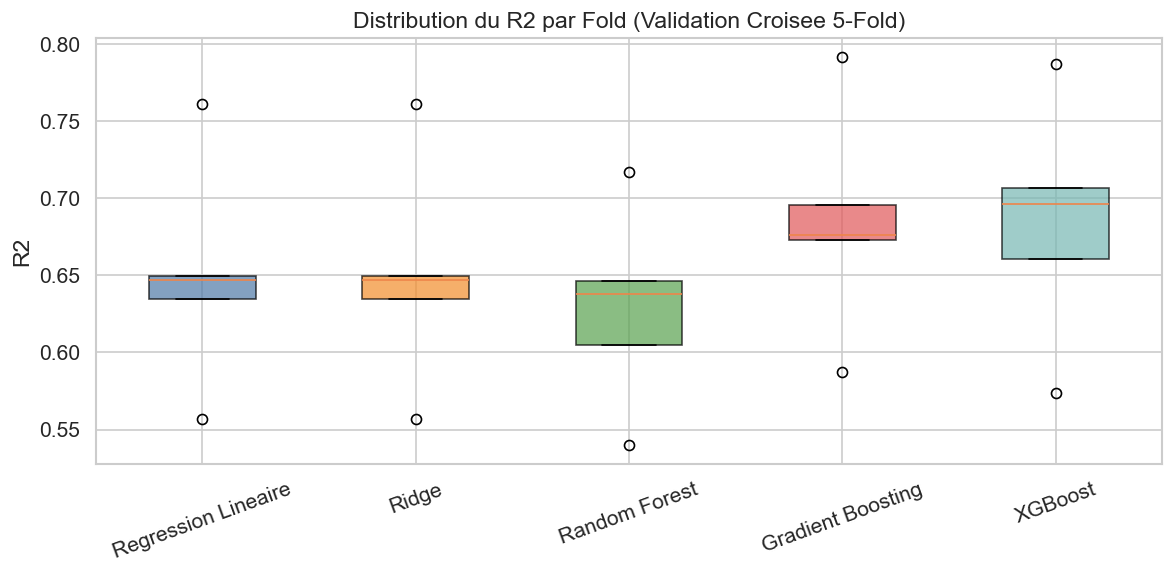

In [16]:
# Validation croisée k=5 sur l'ensemble complet des données
# Principe : le dataset est divisé en 5 blocs (folds)
# Le modèle est entraîné sur 4 blocs et testé sur le 5ème, 5 fois en rotation
# Cela donne une estimation plus fiable de la performance réelle (moins de variance que train/test unique)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# Pipeline enchaîne automatiquement le scaler et le modèle pour éviter les fuites de données

X_full = df_model.drop(columns=["Exam_Score"])  # Features complètes (avant split)
y_full = df_model["Exam_Score"]                  # Cible complète

resultats_cv = {}

for nom, modele in modeles.items():
    # Construction d'un pipeline : StandardScaler -> Modele
    # Chaque fold sera normalisé indépendamment pour éviter le data leakage
    pipeline = Pipeline([
        ("scaler", StandardScaler()),  # Etape 1 : normalisation
        ("modele", modele)             # Etape 2 : modèle
    ])

    # cross_val_score retourne un tableau de k scores (un par fold)
    # scoring='r2' utilise R² comme métrique | cv=5 = 5 folds
    scores = cross_val_score(pipeline, X_full, y_full, cv=5, scoring="r2", n_jobs=-1)
    resultats_cv[nom] = scores

    print(f"{nom:30s} -> R2 moyen = {scores.mean():.4f} (+/- {scores.std():.4f})")

# ── Visualisation des distributions de scores par fold ──────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
data_cv = [resultats_cv[nom] for nom in modeles.keys()]
labels  = list(modeles.keys())

# Boxplot : montre la médiane, les quartiles et les valeurs aberrantes pour chaque modèle
bp = ax.boxplot(data_cv, labels=labels, patch_artist=True, notch=False)
colors = ["#4e79a7", "#f28e2b", "#59a14f", "#e15759", "#76b7b2"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title("Distribution du R2 par Fold (Validation Croisee 5-Fold)")
ax.set_ylabel("R2")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 7. Analyse des Prédictions par Intervalles de Performance


In [17]:
# Prédiction sur le jeu de test avec le meilleur modèle
y_pred_final = meilleur_mod.predict(X_test_sc)

# Construction d'un DataFrame de résultats pour faciliter l'analyse
df_pred = X_test.copy()  # Copie des features du jeu de test
df_pred["Score_Reel"]   = y_test.values       # Score réel de l'élève
df_pred["Score_Predit"] = np.round(y_pred_final, 1)  # Score prédit (arrondi à 1 décimale)
df_pred["Erreur_Abs"]   = np.abs(df_pred["Score_Reel"] - df_pred["Score_Predit"])
# Erreur absolue : différence entre réel et prédit (en points de score)

print(f"DataFrame de predictions construit : {df_pred.shape[0]} etudiants")
df_pred[["Score_Reel", "Score_Predit", "Erreur_Abs"]].describe().round(3)


DataFrame de predictions construit : 1322 etudiants


,Score_Reel,Score_Predit,Erreur_Abs
count,1322.000,1322.000,1322.000
mean,67.318,67.346,0.823
std,3.761,2.951,1.774
min,55.000,57.700,0.000
25%,65.000,65.300,0.300
50%,67.000,67.300,0.600
75%,70.000,69.300,1.000
max,98.000,78.700,26.500


In [19]:
# ── Définition des intervalles de performance ──────────────────────────────
# On divise l'espace des scores prédits en 5 catégories pedagogiques

bins   = [0, 60, 65, 70, 75, 110]  # Bornes des intervalles (la dernière est > max réel)
labels = [
    "En difficulte (<60)",       # Eleves nécessitant une intervention urgente
    "Insuffisant (60-65)",        # En dessous de la moyenne, à surveiller
    "Moyen (65-70)",              # Autour de la moyenne
    "Bien (70-75)",               # Au-dessus de la moyenne
    "Excellent (>75)"             # Très bons résultats
]

# pd.cut découpe une variable continue en intervalles discrets
# right=True (defaut) : borne droite incluse -> (60, 65] signifie 60 < x <= 65
df_pred["Intervalle_Predit"] = pd.cut(
    df_pred["Score_Predit"],
    bins=bins,
    labels=labels,
    right=True
)

# Décompte par intervalle
distribution = df_pred["Intervalle_Predit"].value_counts().reindex(labels)
print("Distribution des etudiants par intervalle de score predit :")
print(distribution)
print(f"\nTotal : {distribution.sum()} etudiants")

Distribution des etudiants par intervalle de score predit :
Intervalle_Predit
En difficulte (<60)      5
Insuffisant (60-65)    289
Moyen (65-70)          781
Bien (70-75)           240
Excellent (>75)          7
Name: count, dtype: int64

Total : 1322 etudiants


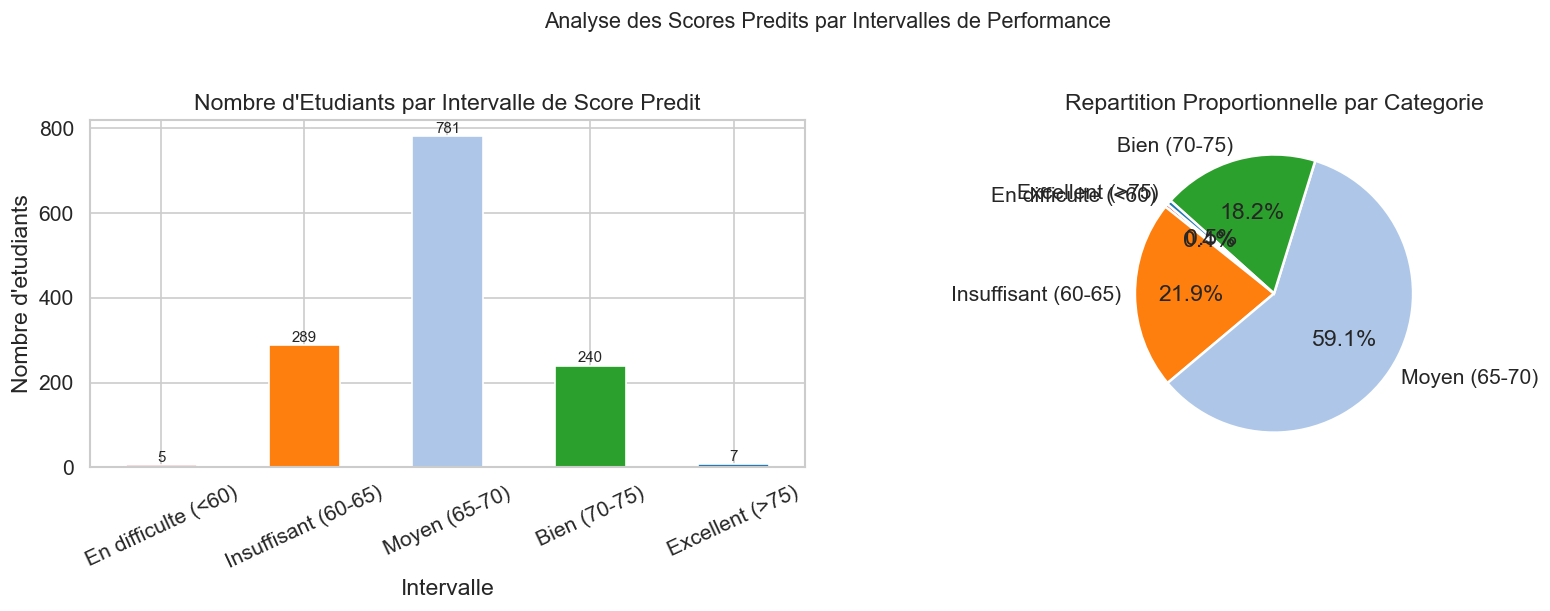

In [20]:
# Visualisation de la distribution par intervalles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Graphique 1 : Nombre d'étudiants par catégorie ────────────────────────
colors_int = ["#d62728", "#ff7f0e", "#aec7e8", "#2ca02c", "#1f77b4"]
distribution.plot(
    kind="bar",
    ax=axes[0],
    color=colors_int,
    edgecolor="white"
)
axes[0].set_title("Nombre d'Etudiants par Intervalle de Score Predit")
axes[0].set_xlabel("Intervalle")
axes[0].set_ylabel("Nombre d'etudiants")
axes[0].tick_params(axis="x", rotation=25)

# Ajout des valeurs sur chaque barre
for i, v in enumerate(distribution.values):
    axes[0].text(i, v + 1, str(v), ha="center", va="bottom", fontsize=9)

# ── Graphique 2 : Camembert (proportions) ─────────────────────────────────
distribution.plot(
    kind="pie",
    ax=axes[1],
    colors=colors_int,
    autopct="%1.1f%%",  # Affiche le pourcentage sur chaque secteur
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[1].set_title("Repartition Proportionnelle par Categorie")
axes[1].set_ylabel("")  # Supprime le label par défaut de pandas pour les pie charts

plt.suptitle("Analyse des Scores Predits par Intervalles de Performance", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Comparaison Reel vs Predit par intervalle :
                     Score_Reel_Moyen  Score_Predit_Moyen  Erreur_Abs_Moyenne  \
Intervalle_Predit                                                               
En difficulte (<60)            57.400              59.260               1.900   
Insuffisant (60-65)            63.225              63.535               1.007   
Moyen (65-70)                  67.383              67.435               0.722   
Bien (70-75)                   72.021              71.555               0.892   
Excellent (>75)                74.857              76.300               1.443   

                     Nb_Etudiants  
Intervalle_Predit                  
En difficulte (<60)             5  
Insuffisant (60-65)           289  
Moyen (65-70)                 781  
Bien (70-75)                  240  
Excellent (>75)                 7  


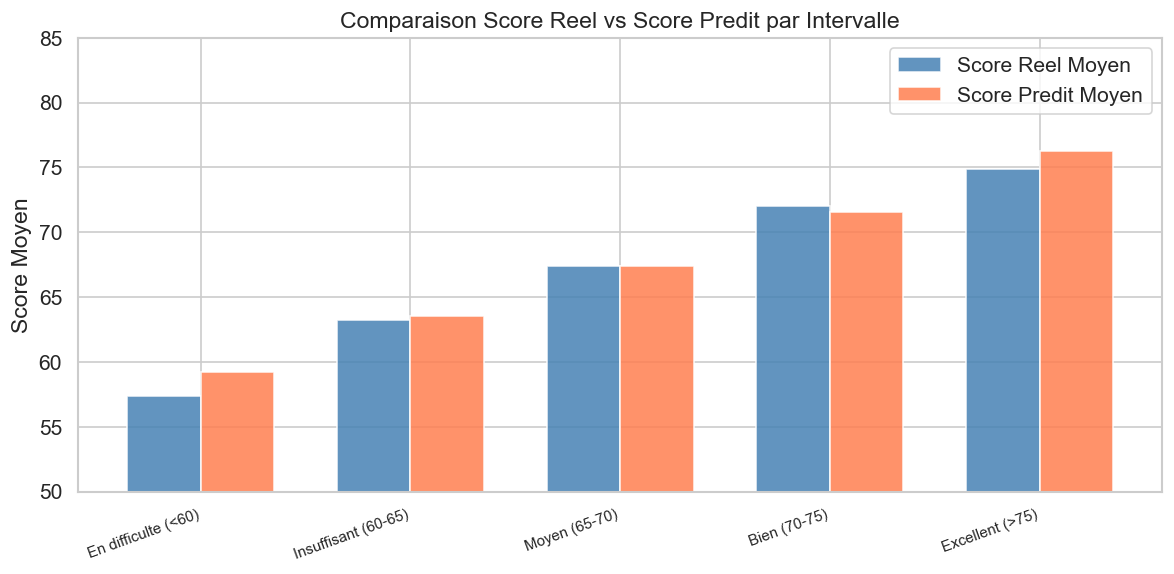

In [21]:
# Analyse comparative : Score réel vs Prédit par intervalle
# Permet de vérifier si les prédictions sont cohérentes avec les scores réels

# Calcul de la moyenne du score réel et prédit pour chaque catégorie prédite
comparaison = df_pred.groupby("Intervalle_Predit")[["Score_Reel", "Score_Predit", "Erreur_Abs"]].agg(
    Score_Reel_Moyen=("Score_Reel", "mean"),
    Score_Predit_Moyen=("Score_Predit", "mean"),
    Erreur_Abs_Moyenne=("Erreur_Abs", "mean"),
    Nb_Etudiants=("Score_Reel", "count")
).reindex(labels)  # Réordonne selon l'ordre naturel des intervalles

print("Comparaison Reel vs Predit par intervalle :")
print(comparaison.round(3))

# Visualisation : score réel moyen vs score prédit moyen
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(labels))
width = 0.35  # Largeur des barres (deux barres côte-à-côte)

ax.bar(x - width/2, comparaison["Score_Reel_Moyen"], width, label="Score Reel Moyen", color="steelblue", alpha=0.85)
ax.bar(x + width/2, comparaison["Score_Predit_Moyen"], width, label="Score Predit Moyen", color="coral", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Score Moyen")
ax.set_title("Comparaison Score Reel vs Score Predit par Intervalle")
ax.legend()
ax.set_ylim(50, 85)  # On limite l'axe y pour mieux voir les différences
plt.tight_layout()
plt.show()

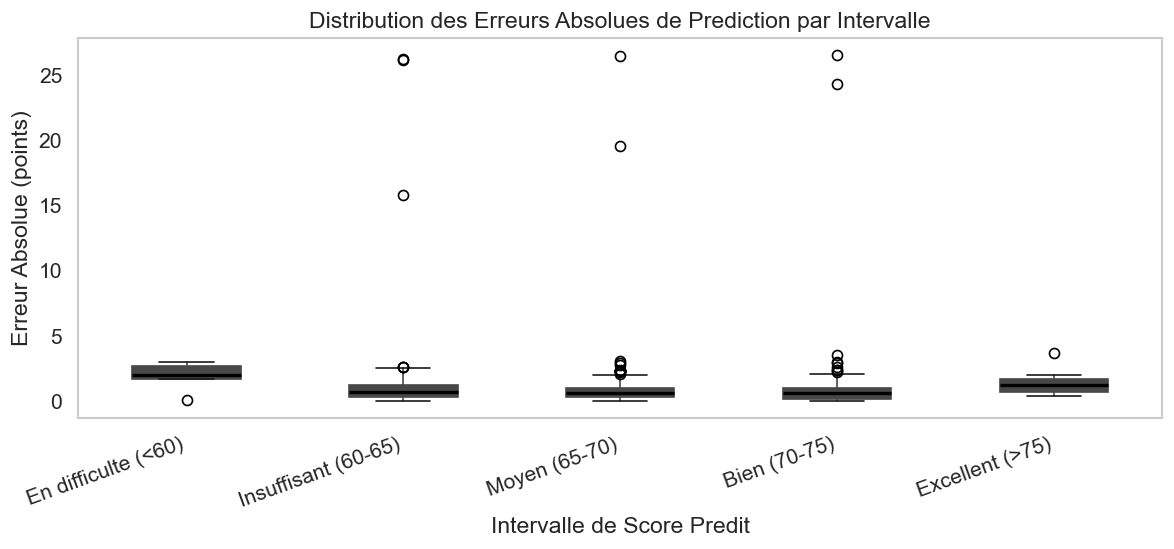

In [22]:
# Distribution des erreurs de prédiction par intervalle (boxplot)
# Un boxplot par catégorie révèle si le modèle est plus ou moins précis selon le niveau de l'élève

fig, ax = plt.subplots(figsize=(10, 5))
df_pred.boxplot(
    column="Erreur_Abs",              # Variable à analyser
    by="Intervalle_Predit",           # Groupement par intervalle
    ax=ax,
    grid=False,                       # Pas de grille en fond
    notch=False,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2)
)
ax.set_title("Distribution des Erreurs Absolues de Prediction par Intervalle")
ax.set_xlabel("Intervalle de Score Predit")
ax.set_ylabel("Erreur Absolue (points)")
plt.suptitle("")  # Supprime le titre automatique de pandas
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


In [23]:
# Analyse des facteurs socio-familiaux pour les élèves "En difficulte"
# On compare les valeurs moyennes des features entre les élèves en difficulté et les excellents

masque_difficulte = df_pred["Intervalle_Predit"] == "En difficulte (<60)"
masque_excellent   = df_pred["Intervalle_Predit"] == "Excellent (>75)"

# On filtre uniquement les features numériques pour comparer les moyennes
features_num = X_test.select_dtypes(include=[np.number]).columns.tolist()

moyennes_diff = df_pred.loc[masque_difficulte, features_num].mean()
moyennes_exc  = df_pred.loc[masque_excellent, features_num].mean()

# DataFrame comparatif
df_comparaison = pd.DataFrame({
    "En difficulte": moyennes_diff,
    "Excellent": moyennes_exc,
    "Difference": moyennes_exc - moyennes_diff  # Différence : positif = l'excellent a plus
})

print("Comparaison des features moyennes : En difficulte vs Excellent")
print(df_comparaison.sort_values("Difference", ascending=False).round(3))

Comparaison des features moyennes : En difficulte vs Excellent
                            En difficulte  Excellent  Difference
Attendance                           63.0     96.571      33.571
Previous_Scores                      63.2     95.143      31.943
Hours_Studied                         9.8     28.429      18.629
Tutoring_Sessions                     0.2      2.714       2.514
Peer_Influence                        0.6      1.857       1.257
Distance_from_Home                    1.0      1.714       0.714
Access_to_Resources                   0.6      0.857       0.257
Extracurricular_Activities            0.6      0.714       0.114
Internet_Access                       1.0      1.000       0.000
Motivation_Level                      1.6      1.571      -0.029
Learning_Disabilities                 0.2      0.143      -0.057
Physical_Activity                     3.2      3.143      -0.057
Family_Income                         1.2      1.000      -0.200
School_Type                

## 8. IA Explicable (XAI) avec SHAP

In [25]:
# SHAP utilise la théorie des jeux de Shapley pour attribuer à chaque feature
# une contribution (positive ou negative) à la prédiction finale
# Formule : prediction = valeur_base + somme_des_valeurs_SHAP

# On utilise le meilleur modèle. Si c'est un modele tree-based, TreeExplainer est optimal
# TreeExplainer est rapide et exact pour Random Forest, XGBoost, Gradient Boosting

# Choix de l'explainer selon le type de modèle
if "XGBoost" in meilleur_nom or "Random Forest" in meilleur_nom or "Gradient" in meilleur_nom:
    explainer = shap.TreeExplainer(meilleur_mod)
    # TreeExplainer exploite la structure interne des arbres pour calculer les valeurs SHAP exactes
else:
    explainer = shap.LinearExplainer(meilleur_mod, X_train_sc)
    # LinearExplainer est utilisé pour les modèles linéaires (Ridge, RegLin)

# Calcul des valeurs SHAP pour le jeu de test
# shap_values est une matrice (n_test, n_features) :
# chaque cellule indique de combien cette feature déplace la prédiction par rapport à la valeur de base
shap_explanation = explainer(X_test_sc)  # Nouvelle API SHAP >= 0.40 : retourne un objet Explanation
shap_values = shap_explanation.values       # Extraction de la matrice numpy des valeurs SHAP

print(f"Matrice SHAP calculee : {shap_values.shape}")
print(f"  Lignes   : {shap_values.shape[0]} etudiants (test set)")
print(f"  Colonnes : {shap_values.shape[1]} features")

Matrice SHAP calculee : (1322, 19)
  Lignes   : 1322 etudiants (test set)
  Colonnes : 19 features


Summary Plot SHAP (Importance Globale) :


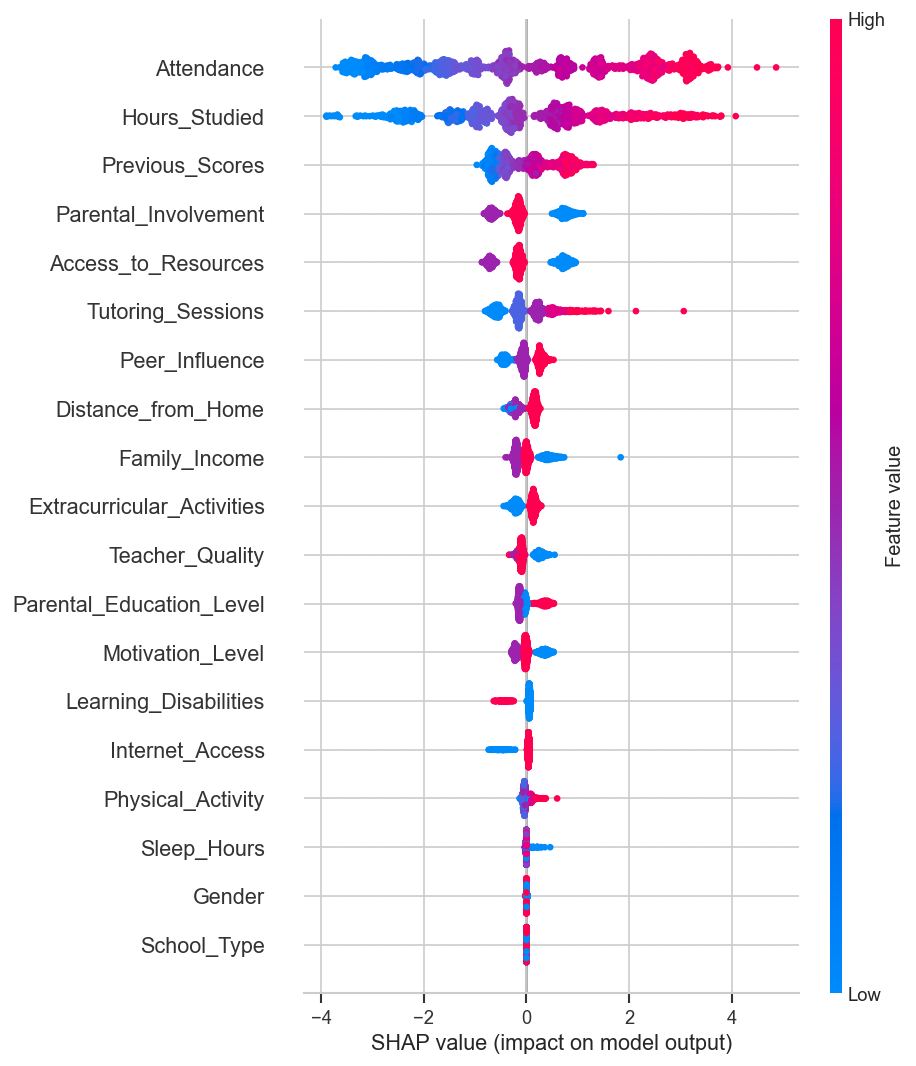

In [26]:
# ── SHAP Global : Importance des features ─────────────────────────────────
# Le Summary Plot (beeswarm) est la visualisation SHAP la plus informative
# Chaque point = un étudiant du test set
# Axe X = valeur SHAP de la feature (contribution positive ou négative au score)
# Couleur = valeur de la feature (rouge=haute, bleu=basse)

print("Summary Plot SHAP (Importance Globale) :")
shap.summary_plot(
    shap_values,           # Matrice des valeurs SHAP
    X_test,                # DataFrame des features (pour les noms des colonnes et valeurs)
    plot_type="dot",       # "dot" = beeswarm | alternativement "bar" pour les barres d'importance
    show=True              # Affiche immédiatement le graphique
)
# Interprétation :
# - Une feature en haut de l'axe Y a un impact élevé sur le score
# - Points rouges à droite = valeur élevée de la feature -> hausse du score prédit
# - Points bleus à droite = valeur élevée de la feature -> baisse du score prédit


Bar Plot SHAP (Importance Absolue Moyenne) :


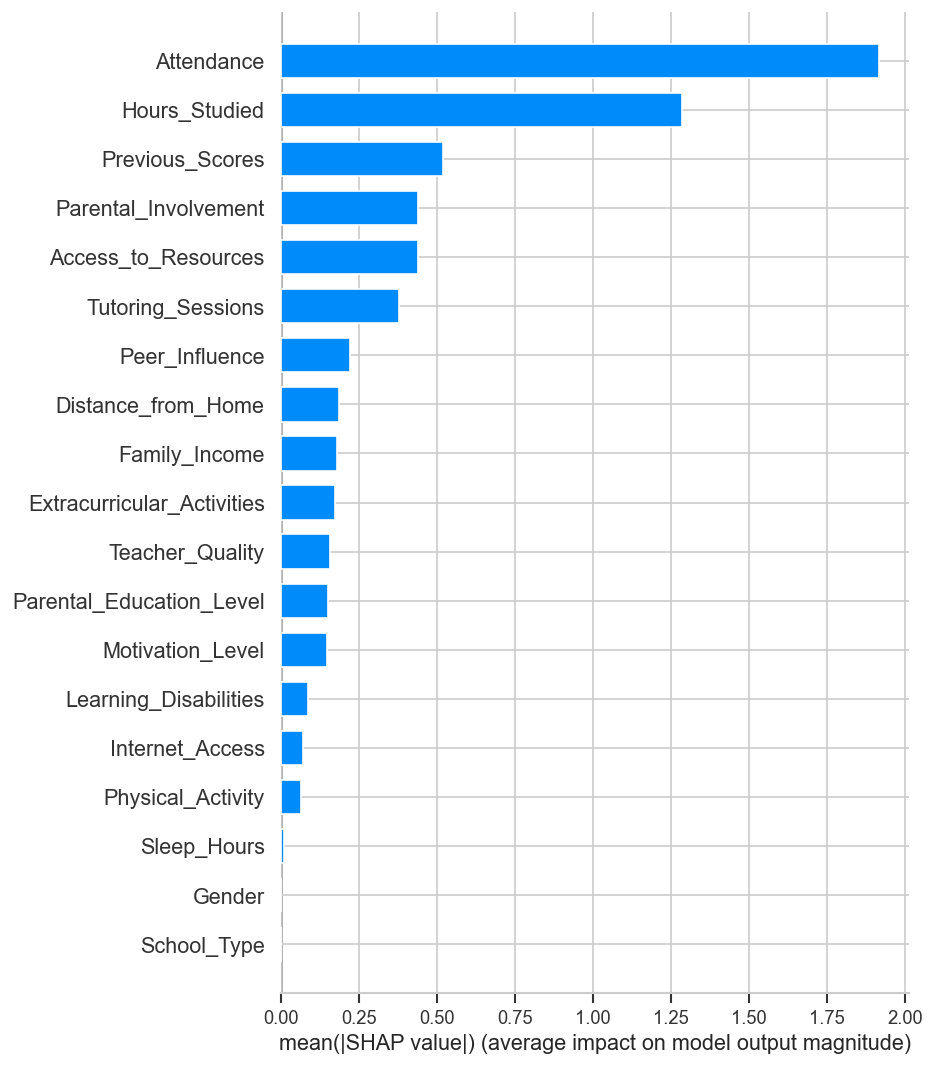

In [27]:
# ── SHAP Bar Plot : Importance moyenne absolue ─────────────────────────────
# Plus simple que le beeswarm : montre la contribution moyenne (sans signe) de chaque feature
# Utilé pour un résumé rapide des features les plus influentes

print("Bar Plot SHAP (Importance Absolue Moyenne) :")
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",  # Chaque barre = moyenne(|SHAP|) pour la feature
    show=True
)

Analyse SHAP pour l etudiant #1101
  Score reel   : 55
  Score predit : 57.7



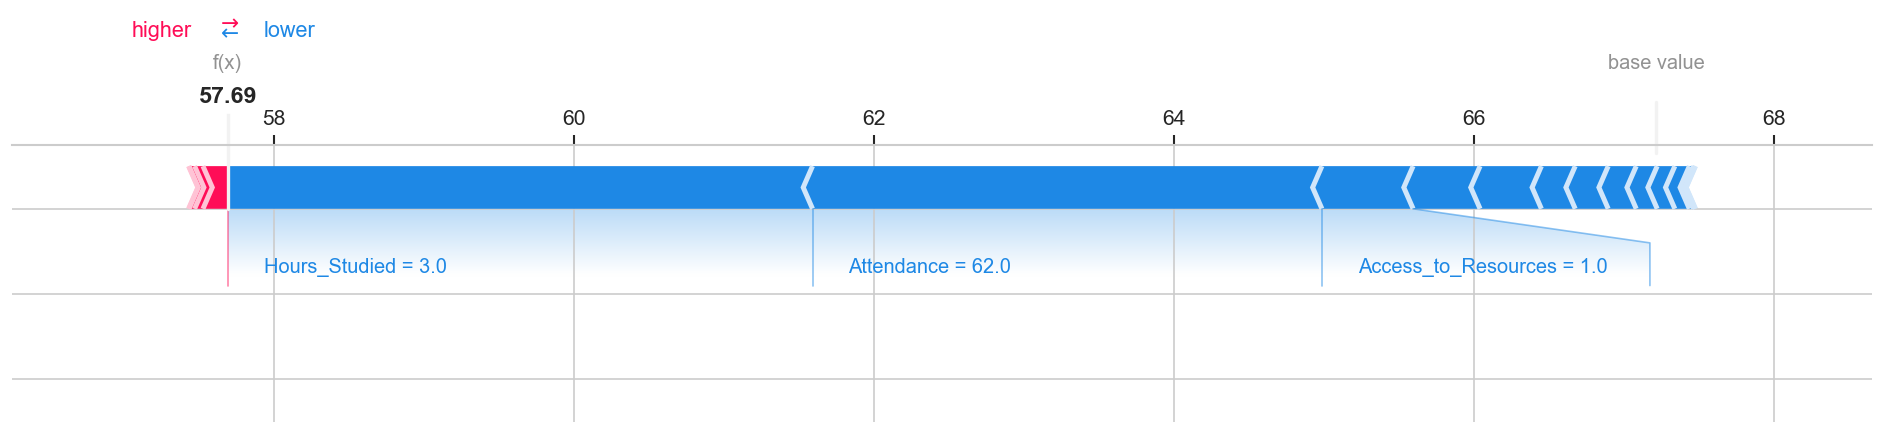

In [28]:
# SHAP Local : Explication pour UN etudiant specifique
# Le Force Plot montre comment chaque feature contribue positivement (rouge) ou negativement (bleu) a la prediction

indices_difficulte = df_pred[df_pred["Intervalle_Predit"] == "En difficulte (<60)"].index

if len(indices_difficulte) > 0:
    etudiant_idx = indices_difficulte[0]
    pos = list(X_test.index).index(etudiant_idx)
    score_reel   = df_pred.loc[etudiant_idx, "Score_Reel"]
    score_predit = df_pred.loc[etudiant_idx, "Score_Predit"]
    print(f"Analyse SHAP pour l etudiant #{etudiant_idx}")
    print(f"  Score reel   : {score_reel}")
    print(f"  Score predit : {score_predit}")
    print()
else:
    pos = 0
    print("Aucun etudiant en difficulte. Analyse sur le premier etudiant du test.")

# shap_explanation[pos] = objet Explanation pour l etudiant a la position pos
# base_values = prediction si on ignorait toutes les features (valeur de base du modele)
# values = contributions de chaque feature (valeurs SHAP)
shap.force_plot(
    shap_explanation[pos].base_values,   # Valeur de base (float scalaire)
    shap_explanation[pos].values,         # Vecteur SHAP de l etudiant
    X_test.iloc[pos, :],                  # Features reelles de l etudiant
    matplotlib=True,
    show=True
)
# Rouge -> hausse le score predit | Bleu -> baisse le score predit
# La longueur de chaque barre = amplitude de l impact de la feature

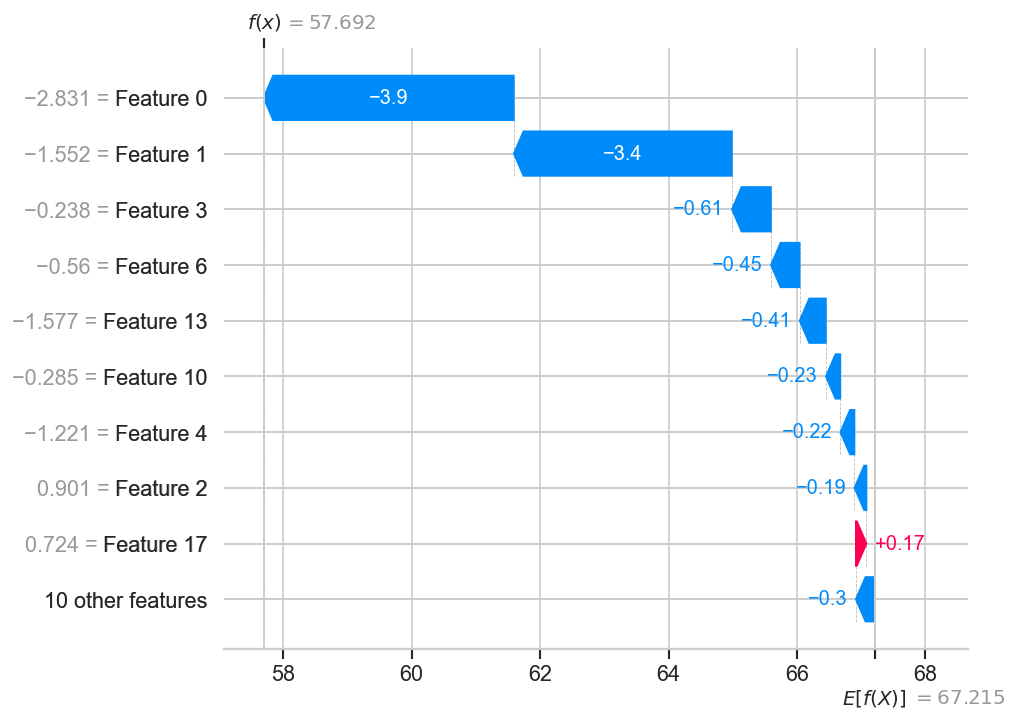

In [29]:
# SHAP Waterfall Plot : Decomposition cumulative de la prediction
# Plus lisible que le Force Plot : les contributions s accumulent pas-a-pas
# On part de E[f(X)] et on ajoute/soustrait chaque contribution jusqu a la prediction finale

shap.waterfall_plot(
    shap_explanation[pos],  # Objet Explanation pour l etudiant deja selectionne ci-dessus
    show=True
)
# Lecture : barre rouge = feature augmente le score | barre bleue = feature diminue le score
# La somme finale correspond exactement au Score_Predit de l etudiant


Feature la plus influente : Attendance


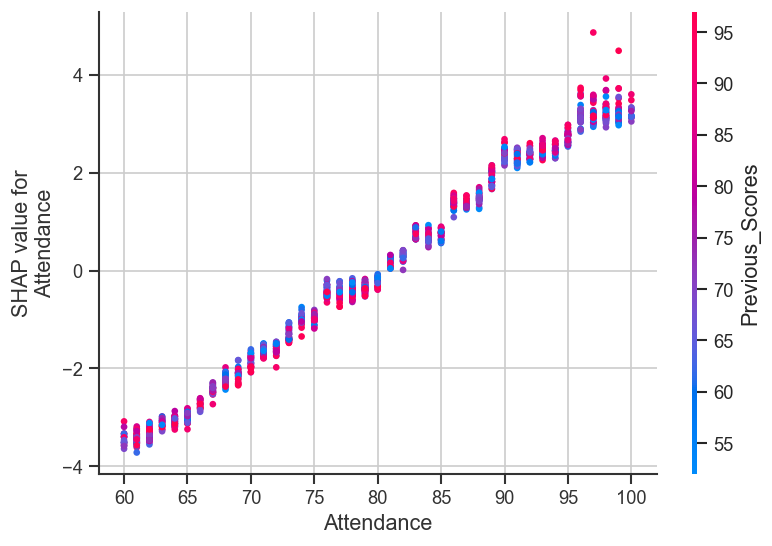

In [30]:
# ── SHAP Dependence Plot : Interaction entre une feature et le score ────────
# Ce graphique montre comment une feature continue influence les valeurs SHAP
# La couleur représente l'interaction avec une deuxième feature (choisie automatiquement)

# On prend la feature la plus influente (celle avec la valeur SHAP absolue moyenne la plus élevée)
importance_globale = np.abs(shap_values).mean(axis=0)
# np.abs() : valeur absolue de chaque SHAP | .mean(axis=0) : moyenne sur tous les étudiants
feature_principale = X_test.columns[np.argmax(importance_globale)]
# argmax() retourne l'indice de la valeur maximale

print(f"Feature la plus influente : {feature_principale}")

shap.dependence_plot(
    feature_principale,          # Feature à analyser sur l'axe X
    shap_values,                 # Matrice SHAP
    X_test,                      # DataFrame des features
    interaction_index="auto",    # Sélection automatique de la feature d'interaction (couleur)
    show=True
)
# Interprétation :
# - Axe X : valeur de la feature principale
# - Axe Y : valeur SHAP (contribution positive ou négative au score)
# - Couleur : valeur d'une feature d'interaction choisie automatiquement par SHAP
